# Unit Commitment MILP with Solar, Wind, and Battery Storage

This notebook formulates and solves a 24-hour **unit commitment mixed-integer linear programming (MILP)** problem containing:

- thermal generators,
- solar generation,
- wind generation,
- battery energy storage,
- startup and shutdown decisions,
- ramp-rate constraints, and
- a battery degradation / throughput cost.

## 1. Model formulation

### Decision variables

* $P_{g,t}\ge 0$ denotes power output of thermal generator $g$ during hour $t$ [MW].
* $u_{g,t}\in\{0,1\}$ denotes commitment status of generator $g$ at hour $t$.

$$
u_{g,t} =
\begin{cases}
1,& \text{generator is ON}\\
0,& \text{generator is OFF}
\end{cases}
$$

* $v_{g,t}\in\{0,1\}$ denotes a startup indicator. $v_{g,t}=1$ if generator $g$ starts at hour $t$.
* $w_{g,t}\in\{0,1\}$ denotes a shutdown indicator. $w_{g,t}=1$ if generator $g$ shuts down at hour $t$.
* $P_{s,t}\ge 0$ is the *utilized* solar power during hour $t$ [MW].
* $P_{w,t}\ge 0$ is the *utilized* wind power during hour $t$ [MW].
* $P_{ch,t}\ge 0$ is the battery charging power during hour $t$ [MW].
* $P_{dis,t}\ge 0$ is the battery discharging power during hour $t$ [MW].
* $E_t\ge 0$ is the energy stored in the battery *at the end* of hour $t$ [MWh].
* $z_t\in\{0,1\}$ is the battery operating mode:
    - If $z_t=1$: charging is allowed and discharging is blocked;
    - If $z_t=0$: discharging is allowed and charging is blocked.

### Fixed parameters

For the thermal generators:
* $P_g^{min}, P_g^{max}$ are the min and max power output of generator $g$ [MW].
* $c_g$ is the marginal operating cost of generator $g$ [\$/MWh].
* $c_g^{SU}$ is the startup cost of generator $g$ [\$].
* $R_g^{up}, R_g^{down}$ are the ramp-up and ramp-down limits [MW/h].
* $u_g^{init}$ is the initial commitment status of generator $g$.
* $P_g^{init}$ is the initial power output of generator $g$ [MW].

For the solar and wind energy:
* $D_t$ is the electricity demand during hour $t$ [MW].
* $S_t^{avail}$ is the available solar power during hour $t$ [MW].
* $W_t^{avail}$ is the available wind power during hour $t$ [MW].

For the battery:
* $P_{ch}^{max}$ is the maximum charging power [MW].
* $P_{dis}^{max}$ is the maximum discharging power [MW].
* $E^{max}$ is the maximum stored battery energy [MWh].
* $E^{init}$ is the initial stored battery energy [MWh].
* $\eta_{ch},\quad \eta_{dis}$ are the Charging and discharging efficiencies.
* $c_B$ is the battery degradation / throughput cost [\$/MWh of battery throughput].

Battery throughput is defined as the sum of charging and discharging energy processed during an hour.

## 2. Objective function

The objective is to minimize total thermal operating cost, thermal startup cost, and battery throughput cost:

$$
\min \sum_{t\in T} \left[ \sum_{g\in G} \left(c_g P_{g,t} + c_g^{SU}v_{g,t} \right) + c_B\left(P_{ch,t}+P_{dis,t}\right) \right]
$$

Solar and wind are assumed to have zero marginal operating cost.

The battery term discourages unnecessary cycling because every MWh charged or discharged contributes to degradation cost.

## 3. Constraints

### Power balance

Demand must be met either by thermal generators, renewables, or battery discharging.

$$\sum_{g\in G}P_{g,t} + P_{s,t} + P_{w,t} + P_{dis,t} = D_t + P_{ch,t} \qquad \forall t$$

### Thermal generator operating limits
If $u_{g,t}=0$, then $P_{g,t}=0$. If $u_{g,t}=1$, generator output must remain between its minimum and maximum output.

$$P_g^{min}u_{g,t} \le P_{g,t} \le P_g^{max}u_{g,t} \qquad \forall g,t $$

### Startup and shutdown logic
The status change from $u_{g,t-1}$ to $u_{g,t}$ should match the same status change of $v_{g,t}$ and $w_{g,t}$ within the same time $t$.

$$ u_{g,t}-u_{g,t-1} = v_{g,t}-w_{g,t}$$

### No simultaneous startup and shutdown
The $v_{g,t}$ and $w_{g,t}$ can both be zero at time $t$. But if one of them is 1, the other must be 0. They cannot be both 1 at the same time.

$$ v_{g,t} + w_{g,t} \leq 1 $$

### Ramp-up and Ramp-down limits
While generators are running, their power output is not allowed to jump more than $R_g^{up}$ nor drop more than $R_g^{down}$ from 
$t-1$ to $t$. But during startup and shutdown, these constraints are relaxed.

$$ P_{g,t}-P_{g,t-1} \le R_g^{up}+P_g^{max}v_{g,t}$$
$$ P_{g,t-1}-P_{g,t} \le R_g^{down}+P_g^{max}w_{g,t} $$

### Solar availability
Utilized solar power cannot exceed available solar power:

$$ 0\le P_{s,t}\le S_t^{avail} \qquad \forall t $$

### Wind availability
Utilized wind power cannot exceed available wind power:

$$ 0\le P_{w,t}\le W_t^{avail} \qquad \forall t $$

### Battery energy
Stored energy increases with charging and decreases with discharging:

$$ E_t = E_{t-1} + \eta_{ch}P_{ch,t} - \frac{P_{dis,t}}{\eta_{dis}}$$

### Charging and discharging limits
Charging and discharging power cannot exceed their respective maxima. The $z_t$ prevents simultaneous charging and discharging. 
$$ P_{ch,t}\le P_{ch}^{max}z_t$$
$$ P_{dis,t}\le P_{dis}^{max}(1-z_t) $$

### Battery conditions
Other battery constraints and boundary conditions:
$$ 0\le E_t\le E^{max} \qquad \forall t $$
$$E_{24}=E^{init}$$

In [1]:
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [10]:
G = ["Coal", "Gas", "Diesel"]
T = list(range(1, 25))

Pmin = {"Coal": 80,  "Gas": 50,  "Diesel": 20}
Pmax = {"Coal": 300, "Gas": 200, "Diesel": 120}

c = {"Coal": 28, "Gas": 42, "Diesel": 65}          # $/MWh
c_SU = {"Coal": 1200, "Gas": 800, "Diesel": 400}   # $

R_up = {"Coal": 100, "Gas": 80, "Diesel": 60}      # MW/h
R_down = {"Coal": 100, "Gas": 80, "Diesel": 60}    # MW/h

u_init = {"Coal": 1, "Gas": 0, "Diesel": 0}
P_init = {"Coal": 180, "Gas": 0, "Diesel": 0}

D = {
     1: 140,  2: 135,  3: 130,  4: 128,
     5: 130,  6: 140,  7: 155,  8: 170,
     9: 180, 10: 185, 11: 190, 12: 195,
    13: 190, 14: 185, 15: 180, 16: 185,
    17: 195, 18: 210, 19: 220, 20: 215,
    21: 200, 22: 180, 23: 160, 24: 150
}

S_avail = {
     1: 0,    2: 0,   3: 0,   4: 0,
     5: 0,    6: 5,   7: 15,  8: 30,
     9: 50,  10: 70, 11: 85, 12: 95,
    13: 100, 14: 90, 15: 75, 16: 55,
    17: 30,  18: 10, 19: 0,  20: 0,
    21: 0,   22: 0,  23: 0,  24: 0
}

W_avail = {
     1: 55,  2: 60,  3: 65,  4: 60,
     5: 55,  6: 50,  7: 45,  8: 40,
     9: 35, 10: 35, 11: 40, 12: 45,
    13: 50, 14: 55, 15: 60, 16: 65,
    17: 70, 18: 70, 19: 65, 20: 60,
    21: 60, 22: 55, 23: 55, 24: 55
}

P_ch_max = 100      # MW
P_dis_max = 100     # MW
E_max = 300         # MWh
E_init = 150        # MWh

eta_ch = 0.95
eta_dis = 0.95

c_B = 3.0           # $/MWh of charge + discharge throughput

## 4. Build the Pyomo MILP

In [3]:
model = pyo.ConcreteModel()

# Sets
model.G = pyo.Set(initialize=G)
model.T = pyo.Set(initialize=T, ordered=True)

# -----------------------------
# Decision variables
# -----------------------------
model.P = pyo.Var(model.G, model.T, domain=pyo.NonNegativeReals)

model.u = pyo.Var(model.G, model.T, domain=pyo.Binary)
model.v = pyo.Var(model.G, model.T, domain=pyo.Binary)
model.w = pyo.Var(model.G, model.T, domain=pyo.Binary)

model.P_s = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.P_w = pyo.Var(model.T, domain=pyo.NonNegativeReals)

model.P_ch = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.P_dis = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.E = pyo.Var(model.T, domain=pyo.NonNegativeReals)

model.z = pyo.Var(model.T, domain=pyo.Binary)

## 5. Objective function

In [4]:
def objective_rule(model):
    thermal_cost = sum(c[g] * model.P[g, t] + c_SU[g] * model.v[g, t]
        for g in model.G for t in model.T)

    battery_throughput_cost = sum(c_B * (model.P_ch[t] + model.P_dis[t])
        for t in model.T)

    return thermal_cost + battery_throughput_cost

model.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

## 6. Constraints

In [5]:
def power_balance_rule(model, t):
    return sum(model.P[g, t] for g in model.G) + model.P_s[t] + model.P_w[t] + model.P_dis[t] == D[t] + model.P_ch[t]

model.power_balance = pyo.Constraint(model.T, rule=power_balance_rule)

def min_generation_rule(model, g, t):
    return model.P[g, t] >= Pmin[g] * model.u[g, t]

def max_generation_rule(model, g, t):
    return model.P[g, t] <= Pmax[g] * model.u[g, t]

model.min_generation = pyo.Constraint(model.G, model.T, rule=min_generation_rule)
model.max_generation = pyo.Constraint(model.G, model.T, rule=max_generation_rule)

def commitment_transition_rule(model, g, t):
    if t == 1:
        return model.u[g, t] - u_init[g] == model.v[g, t] - model.w[g, t]
    return model.u[g, t] - model.u[g, t-1] == model.v[g, t] - model.w[g, t]

model.commitment_transition = pyo.Constraint(model.G, model.T, rule=commitment_transition_rule)


def no_simultaneous_start_stop_rule(model, g, t):
    return model.v[g, t] + model.w[g, t] <= 1

model.no_simultaneous_start_stop = pyo.Constraint(
    model.G, model.T,
    rule=no_simultaneous_start_stop_rule
)

def ramp_up_rule(model, g, t):
    if t == 1:
        return model.P[g, t] - P_init[g] <= R_up[g] + Pmax[g] * model.v[g, t]
    return model.P[g, t] - model.P[g, t-1] <= R_up[g] + Pmax[g] * model.v[g, t]

model.ramp_up = pyo.Constraint(model.G, model.T, rule=ramp_up_rule)

def ramp_down_rule(model, g, t):
    if t == 1:
        return P_init[g] - model.P[g, t] <= R_down[g] + Pmax[g] * model.w[g, t]
    return model.P[g, t-1] - model.P[g, t] <= R_down[g] + Pmax[g] * model.w[g, t]

model.ramp_down = pyo.Constraint(model.G, model.T, rule=ramp_down_rule)

def solar_availability_rule(model, t):
    return model.P_s[t] <= S_avail[t]

def wind_availability_rule(model, t):
    return model.P_w[t] <= W_avail[t]

model.solar_availability = pyo.Constraint(model.T, rule=solar_availability_rule)
model.wind_availability = pyo.Constraint(model.T, rule=wind_availability_rule)

def battery_energy_rule(model, t):
    if t == 1:
        return model.E[t] == E_init + eta_ch * model.P_ch[t] - model.P_dis[t] / eta_dis
    return model.E[t] == model.E[t-1] + eta_ch * model.P_ch[t] - model.P_dis[t] / eta_dis

model.battery_energy = pyo.Constraint(model.T, rule=battery_energy_rule)

def battery_capacity_rule(model, t):
    return model.E[t] <= E_max

model.battery_capacity = pyo.Constraint(model.T, rule=battery_capacity_rule)

def charging_limit_rule(model, t):
    return model.P_ch[t] <= P_ch_max * model.z[t]

def discharging_limit_rule(model, t):
    return model.P_dis[t] <= P_dis_max * (1 - model.z[t])

model.charging_limit = pyo.Constraint(model.T, rule=charging_limit_rule)
model.discharging_limit = pyo.Constraint(model.T, rule=discharging_limit_rule)

model.terminal_energy = pyo.Constraint(expr=model.E[24] == E_init)

## 7. Solve the MILP

In [6]:
solver = pyo.SolverFactory("glpk")
results = solver.solve(model, tee=False)

print("Solver status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)
print(f"Optimal objective value = ${pyo.value(model.objective):,.2f}")

Solver status: ok
Termination condition: optimal
Optimal objective value = $61,470.56


## Tabulate the optimal solution


In [7]:
rows = []

for t in T:
    row = {
        "Hour": t,
        "Demand_MW": D[t],
        "Solar_available_MW": S_avail[t],
        "Solar_used_MW": pyo.value(model.P_s[t]),
        "Solar_curtailment_MW": S_avail[t] - pyo.value(model.P_s[t]),
        "Wind_available_MW": W_avail[t],
        "Wind_used_MW": pyo.value(model.P_w[t]),
        "Wind_curtailment_MW": W_avail[t] - pyo.value(model.P_w[t]),
        "Charge_MW": pyo.value(model.P_ch[t]),
        "Discharge_MW": pyo.value(model.P_dis[t]),
        "Battery_energy_MWh": pyo.value(model.E[t]),
    }

    for g in G:
        row[f"{g}_Power_MW"] = pyo.value(model.P[g, t])
        row[f"{g}_On"] = int(round(pyo.value(model.u[g, t])))
        row[f"{g}_Startup"] = int(round(pyo.value(model.v[g, t])))
        row[f"{g}_Shutdown"] = int(round(pyo.value(model.w[g, t])))

    rows.append(row)

df_results = pd.DataFrame(rows)
print(df_results.round(2))

    Hour  Demand_MW  Solar_available_MW  Solar_used_MW  Solar_curtailment_MW  \
0      1        140                   0            0.0                   0.0   
1      2        135                   0            0.0                   0.0   
2      3        130                   0            0.0                   0.0   
3      4        128                   0            0.0                   0.0   
4      5        130                   0            0.0                   0.0   
5      6        140                   5            5.0                   0.0   
6      7        155                  15           15.0                   0.0   
7      8        170                  30           30.0                   0.0   
8      9        180                  50           50.0                   0.0   
9     10        185                  70           70.0                   0.0   
10    11        190                  85           85.0                   0.0   
11    12        195                  95 

## Cost breakdown

In [8]:
thermal_energy_cost = sum(
    c[g] * pyo.value(model.P[g, t])
    for g in G for t in T
)

startup_cost = sum(
    c_SU[g] * pyo.value(model.v[g, t])
    for g in G for t in T
)

battery_throughput = sum(
    pyo.value(model.P_ch[t]) + pyo.value(model.P_dis[t])
    for t in T
)

battery_degradation_cost = c_B * battery_throughput

cost_summary = pd.DataFrame({
    "Component": [
        "Thermal energy cost",
        "Startup cost",
        "Battery degradation / throughput cost",
        "Total objective"
    ],
    "Cost_$": [
        thermal_energy_cost,
        startup_cost,
        battery_degradation_cost,
        pyo.value(model.objective)
    ]
})

print(f"Total battery throughput = {battery_throughput:.2f} MWh")
cost_summary.round(2)

Total battery throughput = 393.82 MWh


,Component,Cost_$
0,Thermal energy cost,60289.11
1,Startup cost,0.00
2,Battery degradation / throughput cost,1181.45
3,Total objective,61470.56


## 8. Plot results

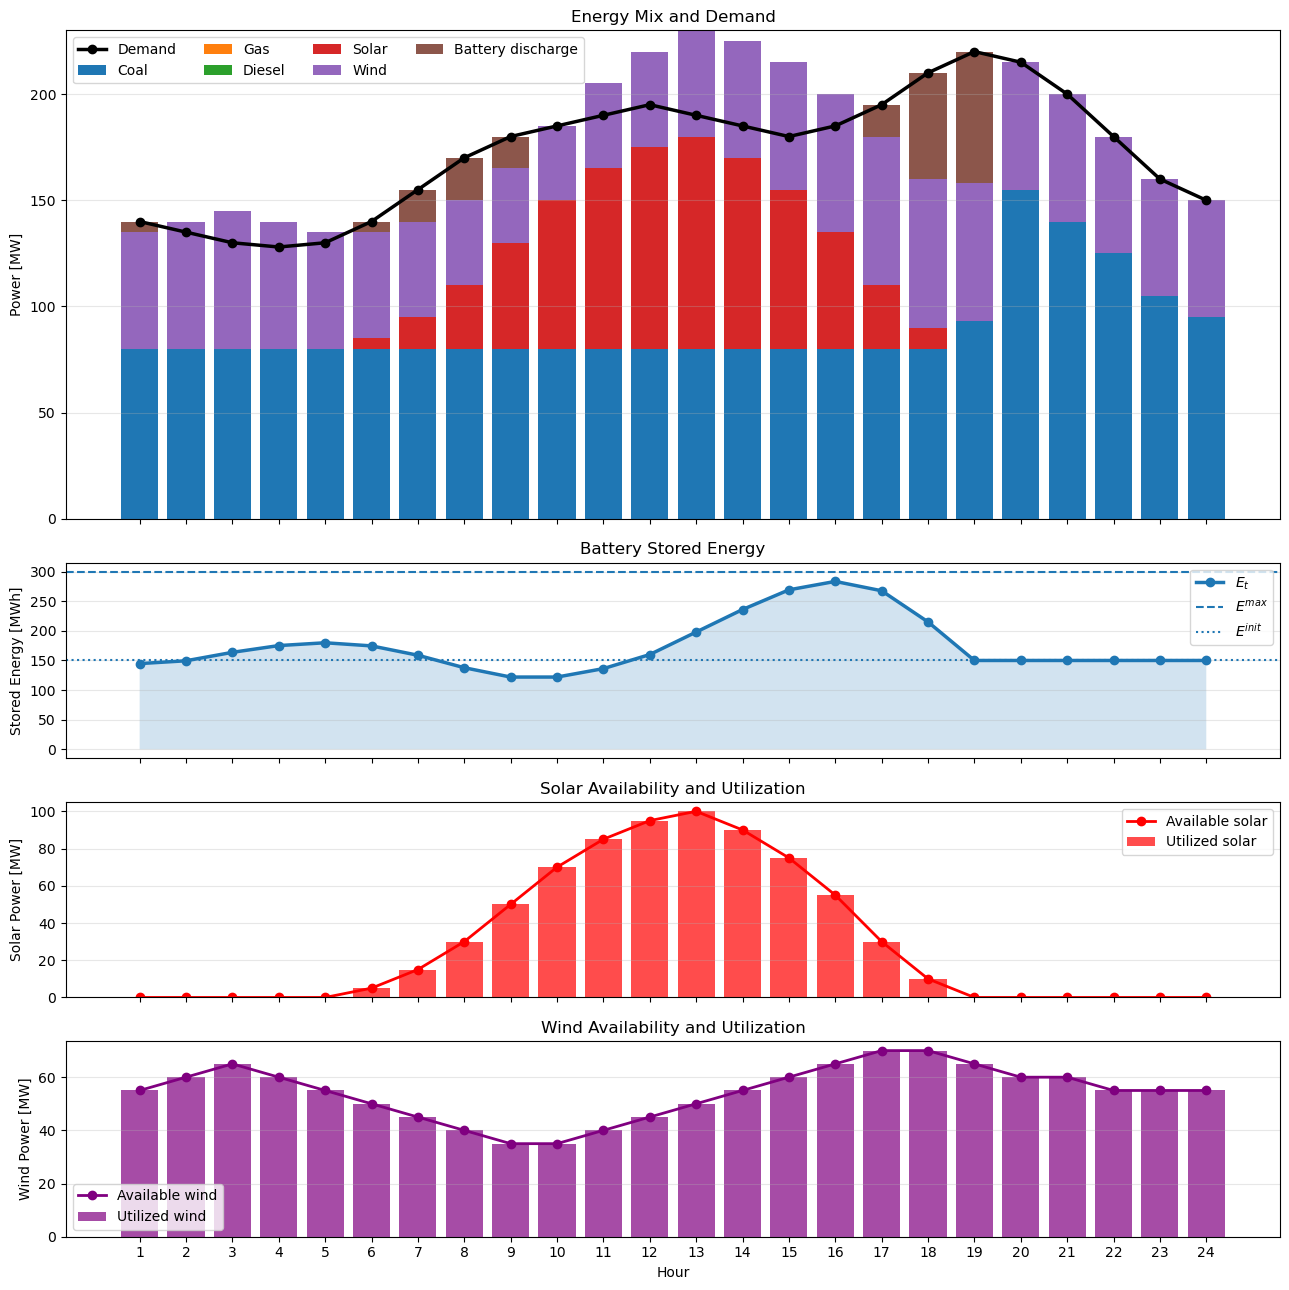

In [9]:
hours = df_results["Hour"]

fig, axes = plt.subplots(4, 1, figsize=(13, 13), 
                         sharex=True, gridspec_kw={"height_ratios": [2.5, 1, 1, 1]})

bottom = np.zeros(len(df_results))

# Thermal generators
for g in G:
    axes[0].bar(hours, df_results[f"{g}_Power_MW"],
        bottom=bottom, label=g)
    bottom += df_results[f"{g}_Power_MW"].values

# Solar
axes[0].bar(hours, df_results["Solar_used_MW"],
    bottom=bottom, label="Solar")
bottom += df_results["Solar_used_MW"].values

# Wind
axes[0].bar(hours, df_results["Wind_used_MW"],
    bottom=bottom, label="Wind")
bottom += df_results["Wind_used_MW"].values

# Battery discharge
axes[0].bar(hours, df_results["Discharge_MW"],
    bottom=bottom, label="Battery discharge")

# Demand line
axes[0].plot(hours, df_results["Demand_MW"],
    marker="o", color='k', linewidth=2.5, label="Demand")

axes[0].set_ylabel("Power [MW]")
axes[0].set_title("Energy Mix and Demand")
axes[0].legend(ncol=4)
axes[0].grid(axis="y", alpha=0.3)

# Battery
axes[1].plot(hours, df_results["Battery_energy_MWh"],
    marker="o", markersize=6, linewidth=2.5, label=r"$E_t$")
axes[1].fill_between(hours, df_results["Battery_energy_MWh"], alpha=0.2)
axes[1].axhline(E_max, linestyle="--", label=r"$E^{max}$")
axes[1].axhline(E_init, linestyle=":", label=r"$E^{init}$")
axes[1].set_ylabel("Stored Energy [MWh]")
axes[1].set_title("Battery Stored Energy")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Solar utilization
axes[2].bar(hours, df_results["Solar_used_MW"], color='r',
            alpha=0.7, label="Utilized solar")
axes[2].plot(hours, df_results["Solar_available_MW"], color='r',
    marker="o", linewidth=2, label="Available solar")
axes[2].set_ylabel("Solar Power [MW]")
axes[2].set_title("Solar Availability and Utilization")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.3)

# Wind utilization
axes[3].bar(hours, df_results["Wind_used_MW"], color='purple', 
            alpha=0.7, label="Utilized wind")
axes[3].plot(hours, df_results["Wind_available_MW"], color='purple',
    marker="o", linewidth=2, label="Available wind")
axes[3].set_ylabel("Wind Power [MW]")
axes[3].set_xlabel("Hour")
axes[3].set_title("Wind Availability and Utilization")
axes[3].legend()
axes[3].grid(axis="y", alpha=0.3)
axes[3].set_xticks(range(1, 25))

plt.tight_layout()
plt.show()